In [45]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, transform
from skimage.color import rgb2hsv, hsv2rgb
from skimage.transform import resize
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from PIL import Image, ImageEnhance, ImageDraw
import shutil
import string
from datetime import datetime
from rembg import remove

In [54]:
def load_data(data_path):
    images = []
    labels = []
    
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"The path {data_path} does not exisdt.")
    
    train_path = os.path.join(data_path, 'train')
    
    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        label = 0 if class_name.lower() == 'husky' else 1

        print(f"Loading {class_name} images...")

        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)

            try:
                img = io.imread(img_path)
                if img is None:
                    print(f"Failed to load {img_path}")
                    continue
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return images, np.array(labels)

def remove_backgrounds(source_dir, output_dir):
    for root, _, files in os.walk(source_dir):
        for file in tqdm(files, desc="Removing backgrounds"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, source_dir)
                output_folder = os.path.join(output_dir, relative_path)
                os.makedirs(output_folder, exist_ok=True)
                output_path = os.path.join(output_folder, os.path.splitext(file)[0] + '.png')

                try:
                    with Image.open(input_path) as img:
                        output = remove(img)  # Remove background
                        output.save(output_path, format='png')
                except Exception as e:
                    print(f"Error processing {input_path}: {e}")

    print("Background removal complete.")
def preprocess_images(images, target_size=(128, 128)):
    processed_images = []

    for img in tqdm(images):
        resized_img = resize(img, target_size, anti_aliasing=True, preserve_range=False)
        flattened_img = resized_img.flatten()
        processed_images.append(flattened_img)

    return np.array(processed_images)
def augment_images(images, labels, target_size=(128, 128, 3)):  # Ensure consistent size
    augmented_images = []
    augmented_labels = []
    rotation_values = [0, 90, 270]

    for img, label in zip(images, labels):
        img = resize(img, target_size, anti_aliasing=True)  # Standardizing input size
        augmented_images.append(img)
        augmented_labels.append(label)

        flipped_img = resize(np.fliplr(img), target_size, anti_aliasing=True)
        flipped_img_vertical = resize(np.flipud(img), target_size, anti_aliasing=True)

        augmented_images.extend([flipped_img, flipped_img_vertical])
        augmented_labels.extend([label, label])

        rotated_img = transform.rotate(img, random.choice(rotation_values))
        rotated_img = resize(rotated_img, target_size, anti_aliasing=True)  # Resize after rotation
        augmented_images.append(rotated_img)
        augmented_labels.append(label)

        if len(img.shape) == 3:
            hsv = rgb2hsv(img)
            hsv[:, :, 2] *= random.uniform(0.1, 0.9)
            darker_img = hsv2rgb(hsv)
            darker_img = resize(darker_img, target_size, anti_aliasing=True)  # Resize after brightness adjustment

            augmented_images.append(darker_img)
            augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)  # No need for np.stack()


def display_samples(images, labels, class_names=['Husky', 'Wolf'], num_samples=5):
    indices = random.sample(range(len(images)), min(num_samples, len(images)))

    plt.figure(figsize=(15, 3 * len(indices)))

    for i, idx in enumerate(indices):
        plt.subplot(len(indices), 1, i + 1)
        img = images[idx]
        plt.imshow(img)
        plt.title(f"Class: {class_names[int(labels[idx])]}")
        plt.axis('off')

    plt.tight_layout()

    plt.show()

In [50]:
src = 'data/train_back'
dest = 'data/train_no_back'
remove_backgrounds(src, dest)

Removing backgrounds: 0it [00:00, ?it/s]
Removing backgrounds: 100%|██████████| 50/50 [00:56<00:00,  1.13s/it]

Background removal complete.


Step 1: Loading data...
Loading husky images...


100%|██████████| 50/50 [00:00<00:00, 153.27it/s]


Loading wolf images...


100%|██████████| 50/50 [00:00<00:00, 60.88it/s]


Loading husky images...


100%|██████████| 50/50 [00:00<00:00, 459.49it/s]


Loading wolf images...


100%|██████████| 50/50 [00:00<00:00, 130.04it/s]


Loaded 100 images with shape (358, 500, 4)


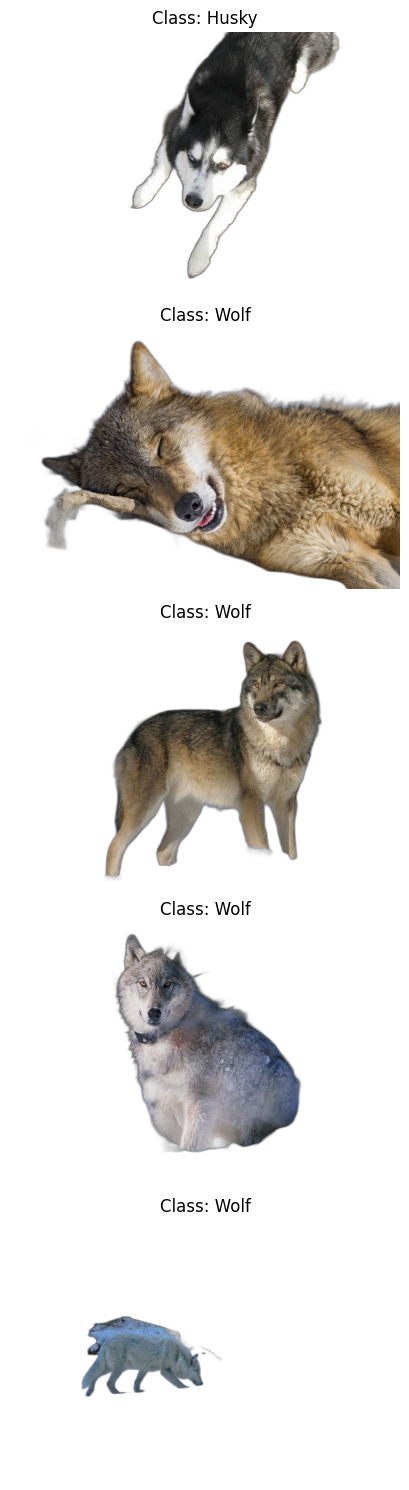

In [63]:
train_no_back_path = 'data/train_no_back'
train_back_path = 'data/train_back'

print("Step 1: Loading data...")
images_no_back, labels_no_back = load_data(train_no_back_path)
images_back, labels_back = load_data(train_back_path)


print(f"Loaded {len(images_no_back)} images with shape {images_no_back[0].shape}")

display_samples(images_no_back, labels_no_back)

In [67]:
from sklearn.model_selection import train_test_split

print("\nStep 2: Splitting data into training and validation sets...")
target_size = (128, 128, 3)

# Function to resize images
def resize_images(images, target_size):
    resized_images = [resize(img, target_size, anti_aliasing=True) for img in images]
    return np.array(resized_images)

# Resize images to the target size
images_no_back = resize_images(images_no_back, target_size)
images_back = resize_images(images_back, target_size)

# Convert labels to NumPy arrays
labels_no_back = np.array(labels_no_back)
labels_back = np.array(labels_back)

# Split the indices into training and validation sets
indices = np.arange(len(images_no_back))
train_indices, val_indices = train_test_split(indices, test_size=0.2, random_state=42, stratify=labels_no_back)

# Create training and validation sets using the split indices
X_train, y_train = images_no_back[train_indices], labels_no_back[train_indices]
X_val, y_val = images_back[val_indices], labels_back[val_indices]

print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")


Step 2: Splitting data into training and validation sets...
Training set: 80 images
Validation set: 20 images



Step 3: Preprocessing data...
Augmenting training images...


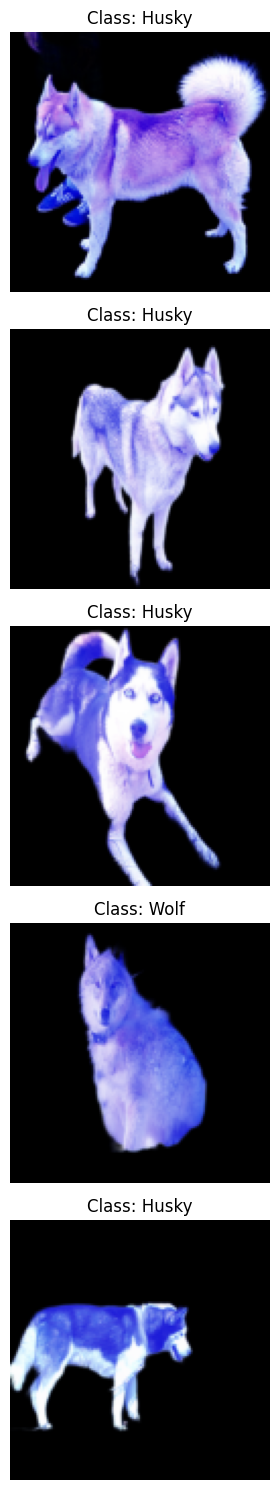


Resizing and normalizing images...


100%|██████████| 20/20 [00:00<00:00, 310.84it/s]


Augmented training set: 400 images


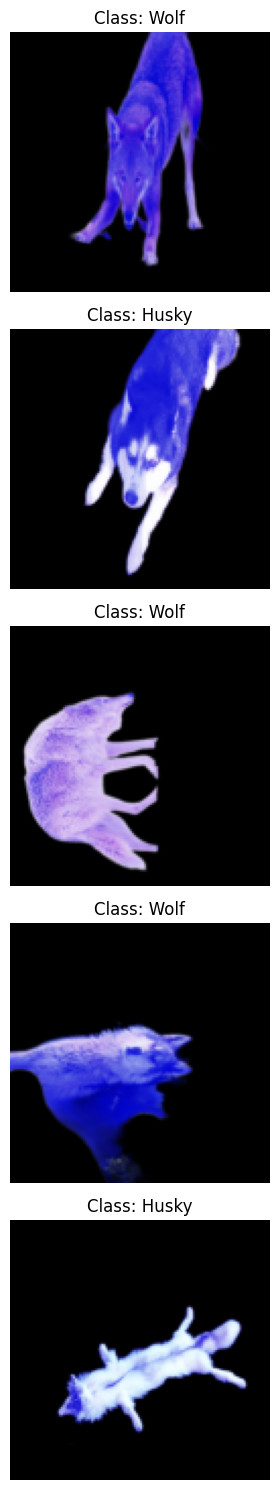

In [68]:
from skimage.color import rgb2gray

print("\nStep 3: Preprocessing data...")
print("Augmenting training images...")
IMG_SHAPE = (128, 128, 3)  # Assuming RGB images

# Convert images to a consistent NumPy format
X_train = np.array([resize(img, IMG_SHAPE) for img in X_train])
y_train = np.array(y_train)

X_val = np.array([resize(img, IMG_SHAPE) for img in X_val])
y_val = np.array(y_val)
display_samples(X_train, y_train)
# Resizing and normalizing images
print("\nResizing and normalizing images...")
X_train_processed = preprocess_images(X_train)
X_val_processed = preprocess_images(X_val)


X_train_aug, y_train_aug = augment_images(X_train, y_train)
print(f"Augmented training set: {len(X_train_aug)} images")

display_samples(X_train_aug, y_train_aug)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.983354016904325..5.813150057656475].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6760392361635854..8.886123059284254].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4876307716041968..4.7856234047958575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7571912794630955..8.887518604924274].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.491899114067911..3.995160526407192].


Processed training set shape: (80, 49152)
Processed validation set shape: (20, 49152)


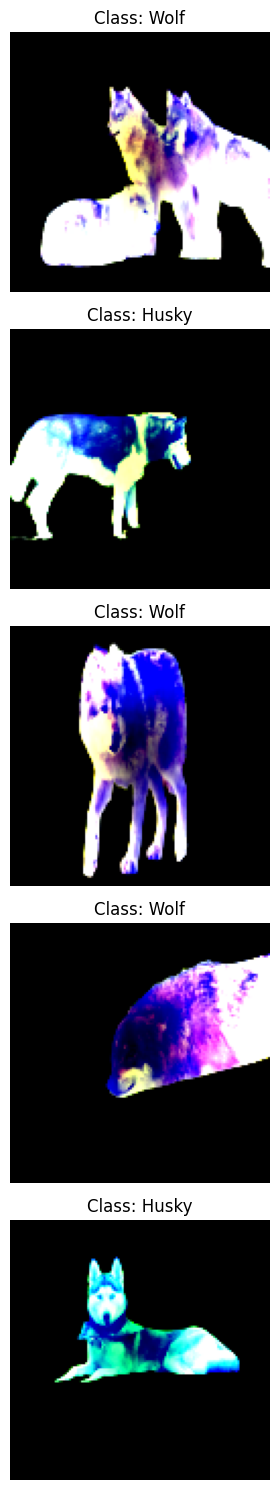

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.4132540834187903..1.8230176326908e+20].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.69395808796281..9.35825503388001e+20].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3272736426287775..6.927589380220307e+20].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.68126846903931..2.2702527400250035e+20].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.3078391129450835..2.8155188722787277e+20].


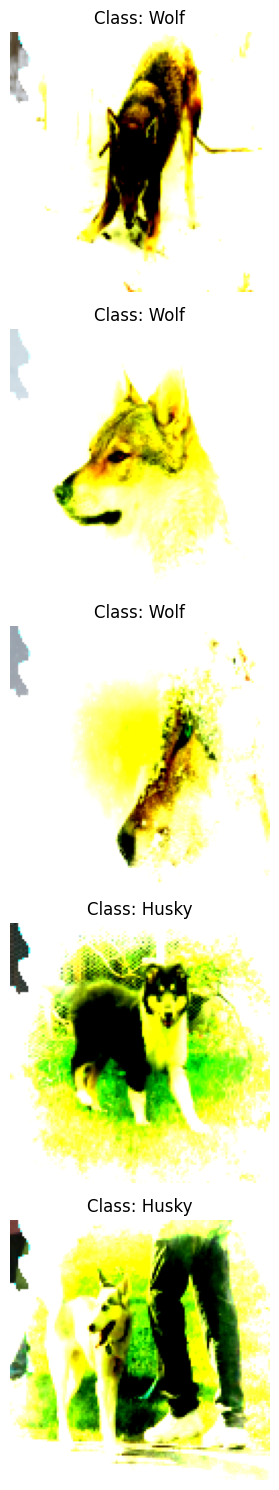

In [69]:


# Scaling the images
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

print(f"Processed training set shape: {X_train_scaled.shape}")
print(f"Processed validation set shape: {X_val_scaled.shape}")

# Reshape the scaled images back to their original dimensions
X_train_reshaped = X_train_scaled.reshape(-1, 128, 128, 3)
X_val_reshaped = X_val_scaled.reshape(-1, 128, 128, 3)

# Display samples
display_samples(X_train_reshaped, y_train)
display_samples(X_val_reshaped, y_val)

In [131]:
class LogisticRegression:
    def __init__(self,lr=0.01,epochs=100, reg_lambda=0.01):
        self.lr = lr
        self.epochs = epochs
        self.reg_lambda = reg_lambda
        self.w = None
        self.b = None

    def sigmoid(self,z):
        return 1/(1+np.exp(-z))

    def loss(self, y_true, y_pred):
        n = len(y_true)
        epsilon = 1e-10  # A small constant to avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Ensure y_pred is never exactly 0 or 1

        # Cross-entropy loss with L2 regularization
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        reg_loss = (self.reg_lambda / (2 * n)) * np.sum(self.w ** 2)
        total_loss = loss + reg_loss

        return total_loss

    def train(self, X, y):
        m, n = X.shape
        X = X.reshape(X.shape[0], -1)

        self.w = np.zeros(n)
        self.b = 0

        for epoch in range(self.epochs):
            # Forward predict
            z = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(z)

            # Compute loss
            loss = self.loss(y, y_pred)

            # Compute gradients with L2 regularization
            dw = (1 / m) * np.dot(X.T, (y_pred - y)) + (self.reg_lambda / m) * self.w
            db = (1 / m) * np.sum(y_pred - y)

            # Update parameters
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Calculate accuracy
            predictions = (y_pred >= 0.5).astype(int)
            accuracy = np.mean(predictions == y)

            print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")


    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        y_pred = self.sigmoid(z)
        return (y_pred>=0.5).astype(int)

In [132]:
model = LogisticRegression(lr=0.01, epochs=100)
print("\nTraining Logistic Regression model...")
# Convert to NumPy array (if not already)
X_train = np.array(X_train)
y_train = np.array(y_train)

# Ensure X_train is properly reshaped to (num_samples, num_features)
X_train = X_train.reshape(X_train.shape[0], -1)  # Reshape training images
X_val = X_val.reshape(X_val.shape[0], -1)        # Reshape validation images
 # Should be (num_samples, features)

# Now train
model.train(X_train, y_train)


# Predictions
y_pred = model.predict(X_val)

# Accuracy
accuracy = np.mean(y_pred == y_val)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")



Training Logistic Regression model...
Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 0.6388, Accuracy: 0.6250
Epoch 2, Loss: 0.9231, Accuracy: 0.5000
Epoch 3, Loss: 3.1901, Accuracy: 0.5000
Epoch 4, Loss: 2.0775, Accuracy: 0.5000
Epoch 5, Loss: 3.2010, Accuracy: 0.5000
Epoch 6, Loss: 1.7717, Accuracy: 0.4875
Epoch 7, Loss: 3.0368, Accuracy: 0.5000
Epoch 8, Loss: 1.6551, Accuracy: 0.4875
Epoch 9, Loss: 2.6911, Accuracy: 0.5000
Epoch 10, Loss: 1.7043, Accuracy: 0.5000
Epoch 11, Loss: 2.3367, Accuracy: 0.5000
Epoch 12, Loss: 1.7258, Accuracy: 0.5000
Epoch 13, Loss: 2.0181, Accuracy: 0.5125
Epoch 14, Loss: 1.6649, Accuracy: 0.5000
Epoch 15, Loss: 1.7338, Accuracy: 0.5375
Epoch 16, Loss: 1.5308, Accuracy: 0.5500
Epoch 17, Loss: 1.4929, Accuracy: 0.5500
Epoch 18, Loss: 1.3672, Accuracy: 0.6000
Epoch 19, Loss: 1.3124, Accuracy: 0.5750
Epoch 20, Loss: 1.2300, Accuracy: 0.6125
Epoch 21, Loss: 1.1910, Accuracy: 0.6250
Epoch 22, Loss: 1.1316, Accuracy: 0.6125
Epoch 23, Loss: 1.1011, Accu

In [133]:
learning_rates = [0.0001,0.001, 0.01, 0.1]
epochs_list = [20,50,100,500,1000]

results = []
best_accuracy = 0
best_lr = None
best_epochs = None

for lr in learning_rates:
    for epochs in epochs_list:
        model = LogisticRegression(lr=lr, epochs=epochs)
        model.train(X_train, y_train)
        y_pred = model.predict(X_val)
        accuracy = np.mean(y_pred == y_val)
        results.append((lr, epochs, accuracy))
        print(f"LR: {lr}, Epochs: {epochs}, Accuracy: {accuracy * 100:.2f}%")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_lr = lr
            best_epochs = epochs

# Display results
import pandas as pd
df_results = pd.DataFrame(results, columns=['Learning Rate', 'Epochs', 'Accuracy'])
print("\nHyperparameter Tuning Results:")
print(df_results)

# Set the best learning rate and epochs
print(f"\nBest Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Accuracy: {best_accuracy * 100:.2f}%")

Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 0.6923, Accuracy: 0.6250
Epoch 2, Loss: 0.6915, Accuracy: 0.6500
Epoch 3, Loss: 0.6907, Accuracy: 0.6625
Epoch 4, Loss: 0.6898, Accuracy: 0.6625
Epoch 5, Loss: 0.6890, Accuracy: 0.6625
Epoch 6, Loss: 0.6883, Accuracy: 0.6625
Epoch 7, Loss: 0.6875, Accuracy: 0.6625
Epoch 8, Loss: 0.6867, Accuracy: 0.6625
Epoch 9, Loss: 0.6859, Accuracy: 0.6625
Epoch 10, Loss: 0.6852, Accuracy: 0.6375
Epoch 11, Loss: 0.6844, Accuracy: 0.6750
Epoch 12, Loss: 0.6837, Accuracy: 0.6750
Epoch 13, Loss: 0.6829, Accuracy: 0.6750
Epoch 14, Loss: 0.6822, Accuracy: 0.6750
Epoch 15, Loss: 0.6815, Accuracy: 0.6625
Epoch 16, Loss: 0.6807, Accuracy: 0.6625
Epoch 17, Loss: 0.6800, Accuracy: 0.6625
Epoch 18, Loss: 0.6793, Accuracy: 0.6625
Epoch 19, Loss: 0.6786, Accuracy: 0.6750
LR: 0.0001, Epochs: 20, Accuracy: 50.00%
Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 0.6923, Accuracy: 0.6250
Epoch 2, Loss: 0.6915, Accuracy: 0.6500
Epoch 3, Loss: 0.6907, Accura

In [61]:
model = LogisticRegression(lr=best_lr, epochs=best_epochs)
model.train(X_train, y_train)
y_pred = model.predict(X_val)
accuracy = np.mean(y_pred == y_val)

print(f"LR: {best_lr}, Epochs: {best_epochs}, Accuracy: {accuracy * 100:.2f}%")

Epoch 0, Loss: 0.6931, Accuracy: 0.5000
Epoch 1, Loss: 0.6923, Accuracy: 0.6250
Epoch 2, Loss: 0.6915, Accuracy: 0.6500
Epoch 3, Loss: 0.6907, Accuracy: 0.6625
Epoch 4, Loss: 0.6898, Accuracy: 0.6625
Epoch 5, Loss: 0.6890, Accuracy: 0.6625
Epoch 6, Loss: 0.6883, Accuracy: 0.6625
Epoch 7, Loss: 0.6875, Accuracy: 0.6625
Epoch 8, Loss: 0.6867, Accuracy: 0.6625
Epoch 9, Loss: 0.6859, Accuracy: 0.6625
Epoch 10, Loss: 0.6852, Accuracy: 0.6375
Epoch 11, Loss: 0.6844, Accuracy: 0.6750
Epoch 12, Loss: 0.6837, Accuracy: 0.6750
Epoch 13, Loss: 0.6829, Accuracy: 0.6750
Epoch 14, Loss: 0.6822, Accuracy: 0.6750
Epoch 15, Loss: 0.6815, Accuracy: 0.6625
Epoch 16, Loss: 0.6807, Accuracy: 0.6625
Epoch 17, Loss: 0.6800, Accuracy: 0.6625
Epoch 18, Loss: 0.6793, Accuracy: 0.6625
Epoch 19, Loss: 0.6786, Accuracy: 0.6750
Epoch 20, Loss: 0.6779, Accuracy: 0.6750
Epoch 21, Loss: 0.6772, Accuracy: 0.6750
Epoch 22, Loss: 0.6765, Accuracy: 0.6750
Epoch 23, Loss: 0.6758, Accuracy: 0.6750
Epoch 24, Loss: 0.6751, Ac

Correctly classified: 10
Incorrectly classified: 10


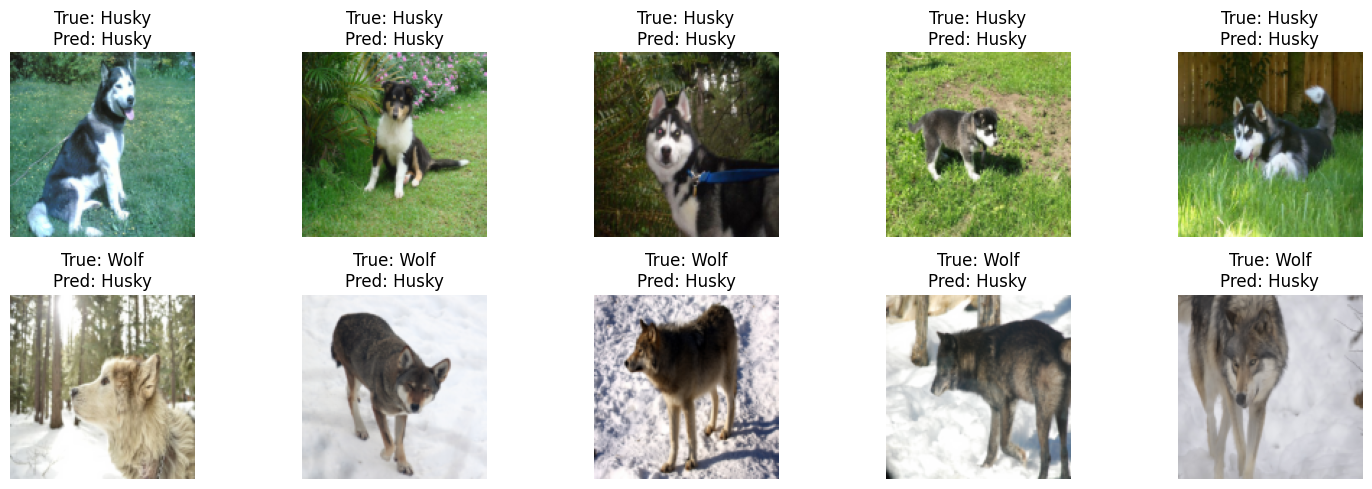

In [73]:
import matplotlib.pyplot as plt

def visualize_classification_results(X_val, y_val, y_pred, class_names=['Husky', 'Wolf'], img_shape=(128, 128, 3)):
    correct_indices = np.where(y_val == y_pred)[0]
    incorrect_indices = np.where(y_val != y_pred)[0]

    print(f"Correctly classified: {len(correct_indices)}")
    print(f"Incorrectly classified: {len(incorrect_indices)}")

    # Display correctly classified images
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(correct_indices[:5]):  # Display up to 5 correct images
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_val[idx].reshape(img_shape))
        plt.title(f"True: {class_names[y_val[idx]]}\nPred: {class_names[y_pred[idx]]}")
        plt.axis('off')

    # Display incorrectly classified images
    for i, idx in enumerate(incorrect_indices[:5]):  # Display up to 5 incorrect images
        plt.subplot(2, 5, i + 6)
        plt.imshow(X_val[idx].reshape(img_shape))
        plt.title(f"True: {class_names[y_val[idx]]}\nPred: {class_names[y_pred[idx]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to visualize the results
visualize_classification_results(X_val, y_val, y_pred)

In [76]:
import os
import random
import shutil

# Define the paths
data_dir = 'data/test'
husky_dir = os.path.join(data_dir, 'husky')
wolf_dir = os.path.join(data_dir, 'wolf')
test_dir = 'data/test_balanced'

# Check if the directories exist
if not os.path.exists(husky_dir):
    raise FileNotFoundError(f"The directory {husky_dir} does not exist.")
if not os.path.exists(wolf_dir):
    raise FileNotFoundError(f"The directory {wolf_dir} does not exist.")

# Create the balanced test directory if it doesn't exist
os.makedirs(test_dir, exist_ok=True)
os.makedirs(os.path.join(test_dir, 'husky'), exist_ok=True)
os.makedirs(os.path.join(test_dir, 'wolf'), exist_ok=True)

# Get the list of images in each class directory
husky_images = os.listdir(husky_dir)
wolf_images = os.listdir(wolf_dir)

# Ensure there are images in both directories
if not husky_images:
    raise ValueError(f"No images found in {husky_dir}.")
if not wolf_images:
    raise ValueError(f"No images found in {wolf_dir}.")

# Determine the minimum class size
min_class_size = min(len(husky_images), len(wolf_images))

# Randomly select images from each class
selected_husky_images = random.sample(husky_images, min_class_size)
selected_wolf_images = random.sample(wolf_images, min_class_size)

# Copy the selected images to the balanced test directory
for img in selected_husky_images:
    shutil.copy(os.path.join(husky_dir, img), os.path.join(test_dir, 'husky', img))

for img in selected_wolf_images:
    shutil.copy(os.path.join(wolf_dir, img), os.path.join(test_dir, 'wolf', img))

print(f"Balanced test set created with {min_class_size} images per class.")

Balanced test set created with 60 images per class.


In [77]:
# Load and preprocess the test data
test_data_path = 'data/test_balanced'
test_images, test_labels = load_data(test_data_path)
test_images_processed = preprocess_images(test_images)
test_images_scaled = scaler.transform(test_images_processed)

# Evaluate the model on the test set
y_test_pred = model.predict(test_images_scaled)
test_accuracy = np.mean(y_test_pred == test_labels)
print(f"LR: {best_lr}, Epochs: {best_epochs}, Test Accuracy: {test_accuracy * 100:.2f}%")

Loading husky images...


100%|██████████| 60/60 [00:00<00:00, 60.05it/s]


Loading wolf images...


100%|██████████| 120/120 [00:10<00:00, 11.57it/s]


LR: 0.0001, Epochs: 10, Test Accuracy: 50.00%


/tmp/ipykernel_9952/2269674029.py:9: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


In [20]:
from sklearn.metrics import confusion_matrix

# Load and preprocess the test data
test_data_path = 'data/test_balanced'
test_images, test_labels = load_data(test_data_path)
test_images_processed = preprocess_images(test_images)
test_images_scaled = scaler.transform(test_images_processed)

# Evaluate the model on the test set
y_test_pred = model.predict(test_images_scaled)
test_accuracy = np.mean(y_test_pred == test_labels)
print(f"LR: {best_lr}, Epochs: {best_epochs}, Test Accuracy: {test_accuracy * 100:.2f}%")

# Calculate the confusion matrix
conf_matrix = confusion_matrix(test_labels, y_test_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Extract the number of errors for each class
class_errors = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
for i, errors in enumerate(class_errors):
    print(f"Class {i} errors: {errors}")

Loading husky images...


100%|██████████| 60/60 [00:00<00:00, 115.51it/s]


Loading wolf images...


100%|██████████| 120/120 [00:05<00:00, 20.58it/s]

LR: 0.001, Epochs: 500, Test Accuracy: 62.50%
Confusion Matrix:
[[43 17]
 [28 32]]
Class 0 errors: 17
Class 1 errors: 28


In [106]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, classes_number=2):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.5)

        self.fc1 = nn.Linear(128 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, classes_number)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))

        self.feature_maps = x

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

    def save_grad(self, grad):
        self.gradients = grad

In [116]:
def prepare_data(images, labels):
    images = np.transpose(images, (0, 3, 1, 2))  # Convert to (batch, channels, height, width)
    images_tensor = torch.tensor(images, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    dataset = TensorDataset(images_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    return dataloader

def train_model(model, train_loader, device, num_epochs=15 , learning_rate = 0.0005):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs , labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

def evaluate_model(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    print(f"Validation Accuracy: {100 * correct / total:.2f}%")

In [117]:
def register_hooks(model):
    def save_features(module, input, output):
        model.feature_maps = output

    def save_gradients(module, grad_input, grad_output):
        model.gradients = grad_output[0]

    target_layer = model.conv3  # Choose the last convolutional layer
    target_layer.register_forward_hook(save_features)
    target_layer.register_backward_hook(save_gradients)

def generate_gradcam(model, image, label, device):
    model.to(device)
    model.eval()

    register_hooks(model)

    image = image.unsqueeze(0).to(device)  # Add batch dimension
    image.requires_grad_()

    # Forward pass
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # Backpropagate from the predicted class
    model.zero_grad()
    output[:, pred_class].backward(retain_graph = True)

    # Get the gradients from the last convolutional layer
    gradients = model.gradients.cpu().detach().numpy()[0]
    feature_maps = model.feature_maps.cpu().detach().numpy()[0]

    # Compute weights for each feature map
    weights = np.mean(gradients, axis=(1, 2))

    # Weighted sum of feature maps
    cam = np.zeros(feature_maps.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * feature_maps[i]

    # Normalize heatmap
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (128, 128))  # Resize to match original image
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))  # Normalize

    # Convert to heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    heatmap = heatmap[..., ::-1]  # Convert from BGR to RGB

    # Overlay heatmap on the image
    original = image.cpu().detach().numpy()[0].transpose(1, 2, 0)  # Convert to HWC format
    overlay = (heatmap * 0.4 + original).clip(0, 1)

    # Show result
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Grad-CAM (Class: {label})")
    plt.axis("off")

    plt.show()

In [118]:
X_train = X_train.reshape(80, 128, 128, 3)
X_val = X_val.reshape(-1, 128, 128, 3)
train_loader = prepare_data(X_train, y_train)

# Device Configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model, Loss Function & Optimizer
model = CNN()
criterion = nn.CrossEntropyLoss()

# Train the Model

train_model(model, train_loader, device, num_epochs=10)

val_loader = prepare_data(X_val , y_val)

evaluate_model(model , val_loader , device)

Epoch [1/10], Loss: 7.6219
Epoch [2/10], Loss: 5.4086
Epoch [3/10], Loss: 2.0992
Epoch [4/10], Loss: 0.9006
Epoch [5/10], Loss: 0.2333
Epoch [6/10], Loss: 0.4024
Epoch [7/10], Loss: 0.3140
Epoch [8/10], Loss: 0.0456
Epoch [9/10], Loss: 0.0323
Epoch [10/10], Loss: 0.0511
Validation Accuracy: 75.00%


/home/romia/PycharmProjects/pythonProject/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


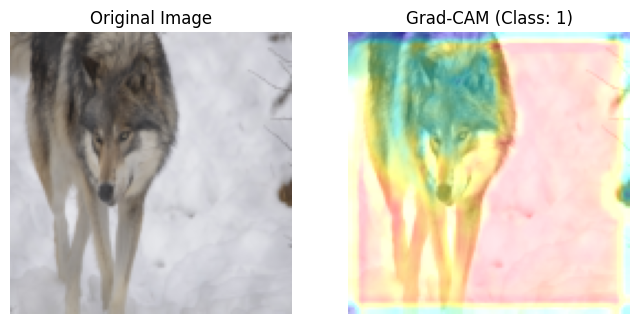

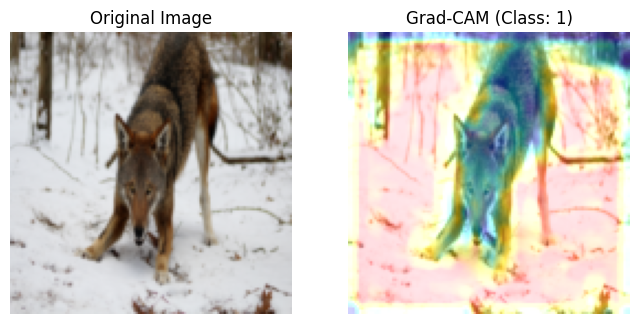

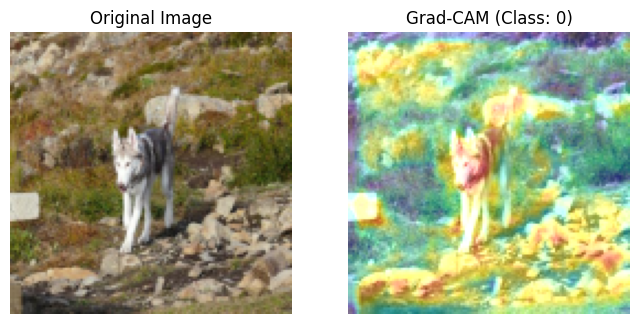

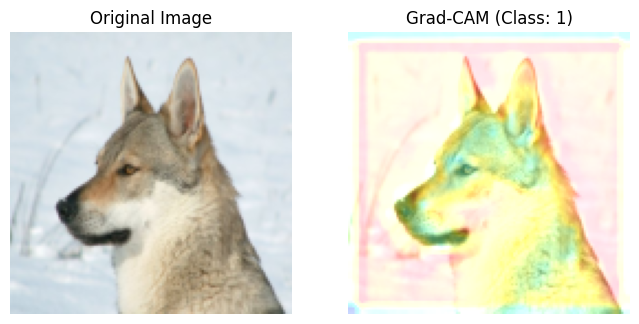

In [124]:
for i in range(4):
    idx = np.random.randint(0, len(X_val))
    sample_image = torch.tensor(X_val[idx].transpose(2, 0, 1), dtype=torch.float32)  # Convert to CHW format
    sample_label = y_val[idx]

    generate_gradcam(model, sample_image, sample_label, device)

In [125]:
import os
import numpy as np
from skimage import io, transform

# Function to load test data
def load_test_data(data_path, target_size=(128, 128, 3)):
    images = []
    labels = []

    if not os.path.exists(data_path):
        raise FileNotFoundError(f"The path {data_path} does not exist.")

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        label = 0 if class_name.lower() == 'husky' else 1

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = io.imread(img_path)
                if img is None:
                    continue
                img = transform.resize(img, target_size, anti_aliasing=True)
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return np.array(images), np.array(labels)

# Load and preprocess test data
test_data_path = 'data/test_balanced'
X_test, y_test = load_test_data(test_data_path)
# Ensure test data has the correct shape
IMG_SHAPE = (128, 128, 3)  # Assuming RGB images
X_test = np.array([transform.resize(img, IMG_SHAPE) for img in X_test])

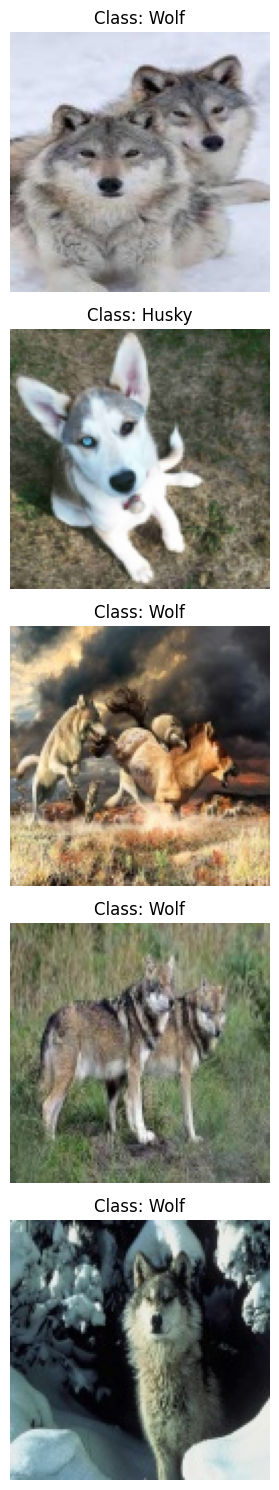

Validation Accuracy: 50.00%


In [126]:
display_samples(X_test, y_test)
test_loader = prepare_data(X_test, y_test)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
X_test = np.array(X_test)
y_test = np.array(y_test)

# Ensure X_train is properly reshaped to (num_samples, num_features)
X_test = X_test.reshape(X_test.shape[0], -1)
X_test = X_test.reshape(-1, 128, 128, 3)
# Train the Model

# train_model(model, train_loader, device, num_epochs=10)
test_loader = prepare_data(X_test, y_test)


evaluate_model(model, test_loader, device)